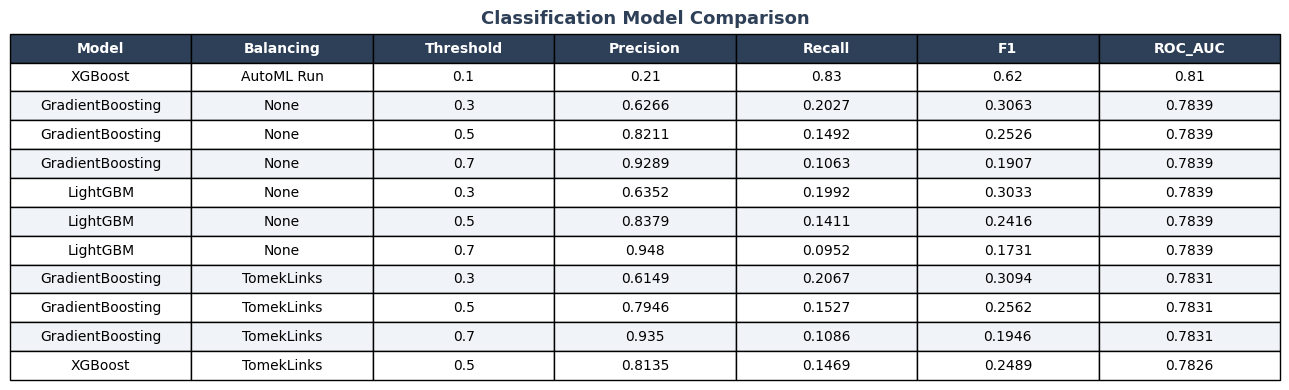

Saved: classification_table.png


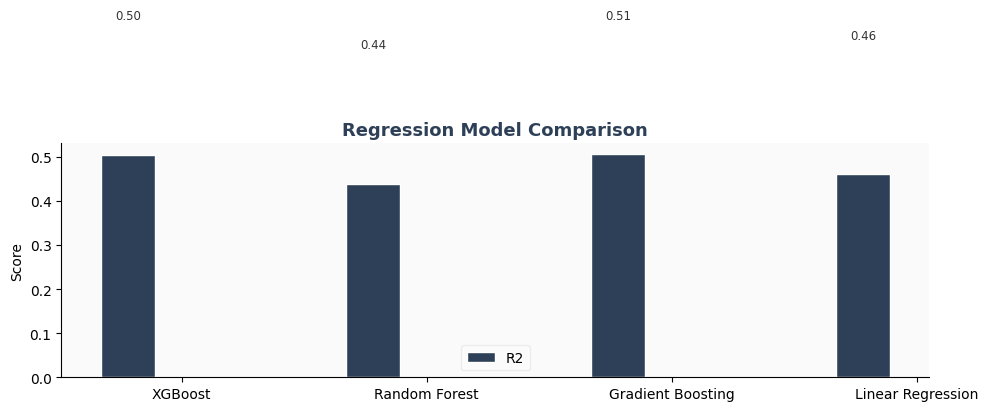

Saved: regression_chart.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ── Dataset 1: Classification Results ──────────────────────────────────────────

d1 = pd.DataFrame({
    "Model":     ["XGBoost","GradientBoosting","GradientBoosting","GradientBoosting",
                  "LightGBM","LightGBM","LightGBM",
                  "GradientBoosting","GradientBoosting","GradientBoosting",
                  "XGBoost"],
    "Balancing": ["AutoML Run","None","None","None","None","None","None",
                  "TomekLinks","TomekLinks","TomekLinks","TomekLinks"],
    "Threshold": [0.1,0.3,0.5,0.7,0.3,0.5,0.7,0.3,0.5,0.7,0.5],
    "Accuracy":  [0.789,0.91,0.9304,0.9289,0.9279,0.9302,0.9283,0.9273,0.9301,0.9292,0.9301],
    "Precision": [0.21,0.6266,0.8211,0.9289,0.6352,0.8379,0.9480,0.6149,0.7946,0.9350,0.8135],
    "Recall":    [0.83, 0.2027,0.1492,0.1063,0.1992,0.1411,0.0952,0.2067,0.1527,0.1086,0.1469],
    "F1":        [0.62,0.3063,0.2526,0.1907,0.3033,0.2416,0.1731,0.3094,0.2562,0.1946,0.2489],
    "ROC_AUC":   [0.81, 0.7839,0.7839,0.7839,0.7839,0.7839,0.7839,0.7831,0.7831,0.7831,0.7826],
})

# Top 5 columns: Model, Balancing, Threshold + top 3 metrics by variance / interest
cols = ["Model", "Balancing", "Threshold", "Precision", "Recall", "F1", "ROC_AUC"]
d1_top = d1[cols].copy()

fig1, ax1 = plt.subplots(figsize=(13, 4))
ax1.axis("off")

table = ax1.table(
    cellText=d1_top.values,
    colLabels=d1_top.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# Header style
header_color = "#2E4057"
for col_idx in range(len(d1_top.columns)):
    cell = table[0, col_idx]
    cell.set_facecolor(header_color)
    cell.set_text_props(color="white", fontweight="bold")

# Alternating row shading
for row_idx in range(1, len(d1_top) + 1):
    bg = "#F0F4F8" if row_idx % 2 == 0 else "white"
    for col_idx in range(len(d1_top.columns)):
        table[row_idx, col_idx].set_facecolor(bg)

plt.title("Classification Model Comparison", fontsize=13, fontweight="bold", pad=12, color="#2E4057")
plt.tight_layout()
plt.savefig("classification_table.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: classification_table.png")


# ── Dataset 2: Regression Results ──────────────────────────────────────────────

d2 = pd.DataFrame({
    "Model": ["XGBoost", "Random Forest", "Gradient Boosting", "Linear Regression"],
    "R2":    [0.5048, 0.4395, 0.5058, 0.4607],
})

metrics   = ["R2"]
bar_colors = ["#2E4057"]

x     = np.arange(len(d2["Model"]))
width = 0.22

fig2, ax2 = plt.subplots(figsize=(10, 5))

for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    bars = ax2.bar(x + i * width, d2[metric], width, label=metric, color=color, edgecolor="white")
    for bar in bars:
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.2f}",
            ha="center", va="bottom", fontsize=8.5, color="#333333"
        )

ax2.set_xticks(x + width)
ax2.set_xticklabels(d2["Model"], fontsize=10)
ax2.set_ylabel("Score", fontsize=10)
ax2.set_title("Regression Model Comparison", fontsize=13, fontweight="bold", color="#2E4057")
ax2.legend(fontsize=10, framealpha=0.3)
ax2.spines[["top", "right"]].set_visible(False)
ax2.set_facecolor("#FAFAFA")
fig2.patch.set_facecolor("white")

plt.tight_layout()
plt.savefig("regression_chart.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: regression_chart.png")